In [2]:
# import json
# import pandas as pd
# target_path = '/Users/debanjansarkar/Desktop/Boot_Camps/spring-2026-LLM-hallucinations/data/processed_mmlu_t1.0_n20.jsonl'
# # Build dataframe
# df = pd.read_json(target_path, lines=True)
# display(df.keys())
# display(df.head())

# Hallucination Detection on MMLU via Semantic Entropy & Embedding Geometry

This notebook applies the Stage 3-4 pipeline on the MMLU (Massive Multitask Language Understanding)
dataset, processed through the same generation+judge framework as DefAn and HaluEval.
Llama-3B generated 20 responses per prompt at temperature 1.0, and GPT-4-mini judged each response.

Key characteristics of MMLU for this analysis:

- MMLU is a multiple-choice benchmark spanning 57 subjects grouped into broader domains
  (Physical Sciences, Social Sciences, Humanities, etc.). The reference answers are
  single letters (A/B/C/D), but the model generates free-form responses that may include
  reasoning chains before (or instead of) giving a letter answer.
- This makes the illogical category particularly interesting: a response that launches into
  an explanation without ever committing to a letter answer may be classified as illogical
  even though it contains partially correct reasoning.
- The `type` column may be empty; domains come from MMLU subject groupings.

The correctness labels from the judge include: correct, hallucination, refused, illogical.
We use strict labeling: binary target counts only correct vs hallucination (excluding
refused/illogical from the majority vote).

References: Farquhar et al. (2024), Ricco et al. (2025), Lee et al. (2018), Hendrycks et al. (2021)

## Setup

In [3]:
# Uncomment if needed:
# !pip install -q sentence-transformers scikit-learn xgboost scipy shap matplotlib seaborn umap-learn

In [4]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.covariance import LedoitWolf
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import ks_2samp
from matplotlib.lines import Line2D
import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print('umap-learn not installed, UMAP plots will be skipped.')

print('Imports loaded.')

Imports loaded.


In [5]:
DATA_PATH = '/Users/debanjansarkar/Desktop/Boot_Camps/spring-2026-LLM-hallucinations/data/processed_mmlu_t1.0_n20.jsonl'
EMBED_CACHE = 'mmlu_embeddings.npy'
OUTPUT_DIR = 'mmlu_output'

SIM_THRESHOLD = 0.85
N_PERMUTATIONS = 10000
N_BOOTSTRAP = 2000
RANDOM_SEED = 42

GEO_FEATURES = ['H_sem', 'D_cos', 'M_bar', 'K', 'sig2_S']

LABEL_COLORS = {
    'correct': '#2196F3',
    'hallucination': '#E53935',
    'refused': '#FFA726',
    'illogical': '#78909C',
}

os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(RANDOM_SEED)

## Load Data

In [6]:
df = pd.read_json(DATA_PATH, lines=True)
print(f'Total rows: {len(df)}')
print(f'Unique questions: {df["prompt_id"].nunique()}')
print(f'Domains: {sorted(df["domain"].dropna().unique())}')
print()

# check the type column -- in MMLU it may be empty
type_vals = df['type'].dropna().replace('', pd.NA).dropna().unique()
if len(type_vals) > 0:
    print(f'Answer types: {sorted(type_vals)}')
else:
    print('Answer type column is empty (expected for MMLU).')
    # create a placeholder so downstream code doesn't break
    df['type'] = 'qa'
print()

print('Correctness distribution (response-level):')
print(df['correctness'].value_counts())
print()

spq = df.groupby('prompt_id').size()
print(f'Samples per question -- min: {spq.min()}, max: {spq.max()}, median: {spq.median()}')

Total rows: 10000
Unique questions: 500
Domains: ['Arts & Literature', 'Computer Science & Engineering', 'Economics & Business', 'General Knowledge', 'History & Geography', 'Life Sciences', 'Mathematics & Logic', 'Philosophy & Religion', 'Physical Sciences', 'Politics & Law', 'error']

Answer type column is empty (expected for MMLU).

Correctness distribution (response-level):
correctness
hallucination    3916
correct          3481
illogical        1776
error             760
refused            67
Name: count, dtype: int64

Samples per question -- min: 20, max: 20, median: 20.0


In [7]:
# peek at the data -- the question column includes the context passage
print('Example question (first 500 chars):')
print(df.iloc[0]['question'][:500])
print()
print(f'Reference answer: {df.iloc[0]["reference_answer"]}')
print(f'Model answer:     {df.iloc[0]["model_answer"]}')
print(f'Correctness:      {df.iloc[0]["correctness"]}')

Example question (first 500 chars):
Positronium is an atom formed by an electron and a positron (antielectron). It is similar to the hydrogen atom, with the positron replacing the proton. If a positronium atom makes a transition from the state with n=3 to a state with n=1, the energy of the photon emitted in this transition is closest to

Reference answer: A
Model answer:     The energy of a hydrogen atom or ion is given by the equation E_{n} = -\frac{13.6}{n^2}eV, where n is the principal quantum number. In this problem, the positronium atom and hydrogen atom have the same ground state energy ( n = 1). However, they both emit photons at frequencies of 1.5 x 10^{15} s^{-1} when transitioning from n = 3 to n = 1, corresponding to wavelengths of 656 nm. When transitioning from n = 2 to n = 1, a hydrogen atom emits a
Correctness:      illogical


## Response-Level EDA: All Judge Labels

MMLU is multiple-choice, so the model often produces verbose reasoning
before (or instead of) a letter answer. We expect a different label distribution
than DefAn or HaluEval: more illogical responses (reasoning without a clear answer)
and potentially more hallucinations (confidently picking the wrong letter).
Refusals may be less common since multiple-choice prompts rarely trigger safety filters.

In [8]:
# determine which labels actually exist
ALL_LABELS = [l for l in ['correct', 'hallucination', 'refused', 'illogical']
              if l in df['correctness'].values]
print(f'Labels present: {ALL_LABELS}')

resp_counts = df['correctness'].value_counts()
resp_pcts = (resp_counts / len(df) * 100).round(1)
print()
print('Response-level label distribution:')
for lab in ALL_LABELS:
    if lab in resp_counts.index:
        print(f'  {lab:15s}: {resp_counts[lab]:6d}  ({resp_pcts[lab]:.1f}%)')

Labels present: ['correct', 'hallucination', 'refused', 'illogical']

Response-level label distribution:
  correct        :   3481  (34.8%)
  hallucination  :   3916  (39.2%)
  refused        :     67  (0.7%)
  illogical      :   1776  (17.8%)


In [9]:
# cross-tab: domain x correctness
ct_domain = pd.crosstab(df['domain'], df['correctness'])
ct_domain = ct_domain.reindex(columns=[c for c in ALL_LABELS if c in ct_domain.columns])
print('Response counts by domain x correctness:')
display(ct_domain)
print()

ct_domain_pct = ct_domain.div(ct_domain.sum(axis=1), axis=0)
print('Proportions:')
display(ct_domain_pct.round(3))

Response counts by domain x correctness:


correctness,correct,hallucination,refused,illogical
domain,,,,
Arts & Literature,40,35,2,1
Computer Science & Engineering,151,264,3,65
Economics & Business,293,451,5,219
General Knowledge,361,403,12,84
History & Geography,322,253,7,46
Life Sciences,628,823,9,87
Mathematics & Logic,124,40,4,534
Philosophy & Religion,650,511,8,261
Physical Sciences,169,343,6,269



Proportions:


correctness,correct,hallucination,refused,illogical
domain,,,,
Arts & Literature,0.513,0.449,0.026,0.013
Computer Science & Engineering,0.313,0.547,0.006,0.135
Economics & Business,0.303,0.466,0.005,0.226
General Knowledge,0.420,0.469,0.014,0.098
History & Geography,0.513,0.403,0.011,0.073
Life Sciences,0.406,0.532,0.006,0.056
Mathematics & Logic,0.177,0.057,0.006,0.761
Philosophy & Religion,0.455,0.357,0.006,0.183
Physical Sciences,0.215,0.436,0.008,0.342


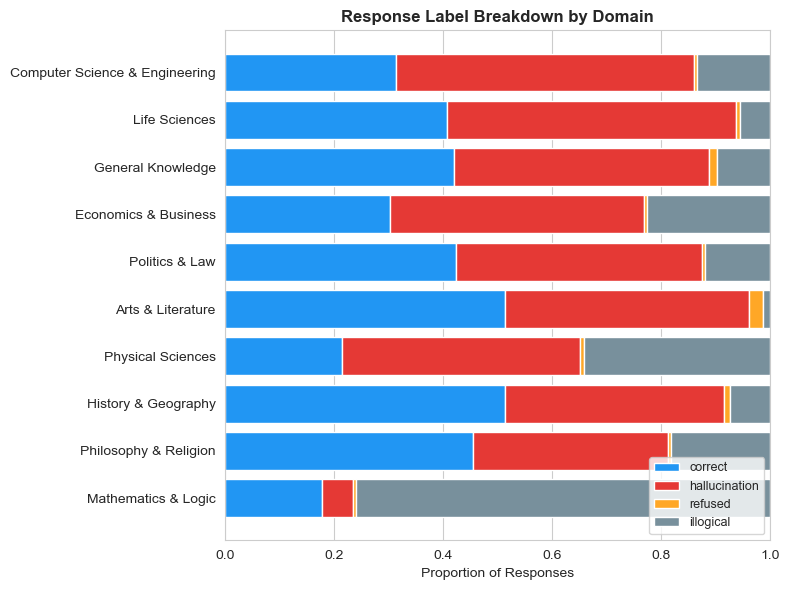

In [10]:
# stacked bar: domain x label proportions

n_panels = 2 if len(df['type'].unique()) > 1 and df['type'].iloc[0] != 'qa' else 1

fig, axes = plt.subplots(1, n_panels, figsize=(8 * n_panels, 6))
if n_panels == 1:
    axes = [axes]

# panel 1: by domain
ct_plot = ct_domain_pct.sort_values(ct_domain_pct.columns[0] if 'hallucination' not in ct_domain_pct.columns else 'hallucination',
                                     ascending=True)
bottom = np.zeros(len(ct_plot))
for lab in ALL_LABELS:
    if lab not in ct_plot.columns:
        continue
    vals = ct_plot[lab].values
    axes[0].barh(ct_plot.index, vals, left=bottom,
                 color=LABEL_COLORS.get(lab, 'gray'), label=lab)
    bottom += vals
axes[0].set_xlabel('Proportion of Responses')
axes[0].set_title('Response Label Breakdown by Domain', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].set_xlim(0, 1)

# panel 2: by type (if meaningful)
if n_panels == 2:
    ct_type = pd.crosstab(df['type'], df['correctness'])
    ct_type = ct_type.reindex(columns=[c for c in ALL_LABELS if c in ct_type.columns])
    ct_type_pct = ct_type.div(ct_type.sum(axis=1), axis=0)
    ct_type_pct = ct_type_pct.sort_values('hallucination', ascending=True)
    bottom = np.zeros(len(ct_type_pct))
    for lab in ALL_LABELS:
        if lab not in ct_type_pct.columns:
            continue
        vals = ct_type_pct[lab].values
        axes[1].barh(ct_type_pct.index, vals, left=bottom,
                     color=LABEL_COLORS.get(lab, 'gray'), label=lab)
        bottom += vals
    axes[1].set_xlabel('Proportion of Responses')
    axes[1].set_title('Response Label Breakdown by Type', fontweight='bold')
    axes[1].legend(loc='lower right', fontsize=9)
    axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig01_response_label_breakdown.png'), dpi=150, bbox_inches='tight')
plt.show()

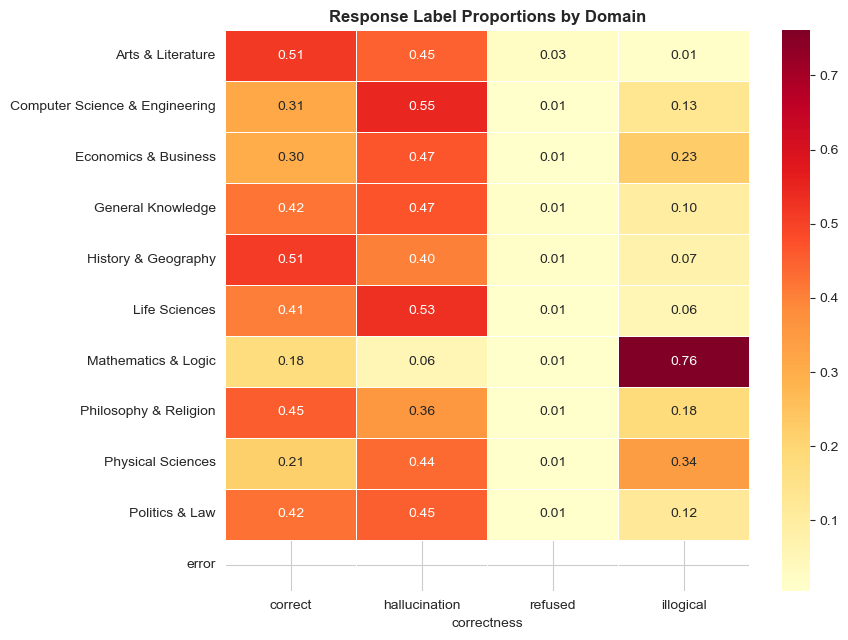

In [11]:
# heatmap
fig, ax = plt.subplots(figsize=(9, max(4, len(ct_domain_pct) * 0.5 + 1)))
sns.heatmap(ct_domain_pct, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=ax, linewidths=0.5, linecolor='white')
ax.set_title('Response Label Proportions by Domain', fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig02_response_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

## Stage 3a: Embed All Responses

We embed the `model_answer` field. For MMLU, responses range from short letter answers
to multi-sentence explanations. The sentence transformer maps them all into 384-dim
unit vectors. Questions where the model consistently gives the same short answer
will have tight embedding clusters (low entropy, low dispersion), while questions
that produce diverse reasoning chains will spread out.

In [ ]:
if os.path.exists(EMBED_CACHE):
    print(f'Loading cached embeddings from {EMBED_CACHE}')
    all_embeddings = np.load(EMBED_CACHE)
    assert all_embeddings.shape[0] == len(df), 'Cache size mismatch!'
else:
    print('Computing embeddings...')
    embedder = SentenceTransformer('all-MiniLM-L6-v2')
    texts = df['model_answer'].astype(str).tolist()
    all_embeddings = embedder.encode(texts, batch_size=256,
                                     show_progress_bar=True,
                                     normalize_embeddings=True)
    np.save(EMBED_CACHE, all_embeddings)
    print(f'Saved to {EMBED_CACHE}')

print(f'Embedding matrix: {all_embeddings.shape}')

Computing embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/40 [00:00<?, ?it/s]

## Stage 3b: Feature Extraction

Same 5 geometric features computed from all 20 response embeddings per question:

1. Semantic entropy $H_{sem}$ -- Shannon entropy over cluster proportions
2. Cosine dispersion $D_{cos}$ -- mean cosine distance from centroid
3. Mahalanobis distance $\bar{M}$ -- distance from the correct-response reference distribution
4. Cluster count $K$
5. Similarity variance $\sigma^2_S$

Binary label uses strict correct-vs-hallucination vote, excluding refused and illogical.

In [ ]:
def semantic_entropy(embs, threshold=SIM_THRESHOLD):
    n = len(embs)
    dist_matrix = np.clip(1.0 - cosine_similarity(embs), 0, 2)
    np.fill_diagonal(dist_matrix, 0)
    clustering = AgglomerativeClustering(
        n_clusters=None, metric='precomputed',
        linkage='average', distance_threshold=1 - threshold
    )
    labels = clustering.fit_predict(dist_matrix)
    _, counts = np.unique(labels, return_counts=True)
    probs = counts / n
    H = -np.sum(probs * np.log2(probs + 1e-12))
    return H, len(counts)


def cosine_dispersion(embs):
    centroid = embs.mean(axis=0, keepdims=True)
    return float(np.mean(1.0 - cosine_similarity(embs, centroid).flatten()))


def mahalanobis_distance(embs, mu, cov_inv):
    diffs = embs - mu
    mahal_sq = np.einsum('ni,ij,nj->n', diffs, cov_inv, diffs)
    mahal_sq = np.clip(mahal_sq, 0, None)
    return float(np.mean(np.sqrt(mahal_sq)))


def similarity_variance(embs):
    sim = cosine_similarity(embs)
    upper = sim[np.triu_indices(len(embs), k=1)]
    return float(np.var(upper))

In [ ]:
# fit reference distribution on correct-labeled responses
correct_mask = (df['correctness'] == 'correct').values
correct_embs = all_embeddings[correct_mask]
print(f'Correct responses for reference: {correct_embs.shape[0]}')

if correct_embs.shape[0] < 10:
    print('WARNING: very few correct responses. Using all embeddings for reference.')
    correct_embs = all_embeddings

mu_ref = correct_embs.mean(axis=0)
lw = LedoitWolf()
lw.fit(correct_embs)
cov_inv = lw.precision_
print(f'Reference fitted. mu: {mu_ref.shape}, precision: {cov_inv.shape}')

In [ ]:
prompt_ids = df['prompt_id'].unique()
records = []
skipped = 0

for i, pid in enumerate(prompt_ids):
    if (i + 1) % 500 == 0:
        print(f'  {i+1}/{len(prompt_ids)} ...')

    mask = df['prompt_id'] == pid
    sub = df[mask]
    idx = np.where(mask.values)[0]
    embs = all_embeddings[idx]
    n = len(sub)

    # count each label
    counts = sub['correctness'].value_counts()
    n_correct   = int(counts.get('correct', 0))
    n_hallu     = int(counts.get('hallucination', 0))
    n_refused   = int(counts.get('refused', 0))
    n_illogical = int(counts.get('illogical', 0))

    # strict label: majority vote on correct vs hallucination only
    n_definitive = n_correct + n_hallu
    if n_definitive == 0:
        skipped += 1
        continue

    hall_rate_strict = n_hallu / n_definitive
    label = 1 if hall_rate_strict > 0.5 else 0

    # geometric features from all 20 embeddings
    H, K = semantic_entropy(embs)
    D = cosine_dispersion(embs)
    M = mahalanobis_distance(embs, mu_ref, cov_inv)
    sig2 = similarity_variance(embs)

    row0 = sub.iloc[0]
    records.append({
        'prompt_id': pid,
        'question': row0['question'],
        'domain': row0['domain'],
        'type': row0['type'],
        'n_samples': n,
        'n_correct': n_correct,
        'n_hallu': n_hallu,
        'n_refused': n_refused,
        'n_illogical': n_illogical,
        'n_definitive': n_definitive,
        'frac_correct': n_correct / n,
        'frac_hallu': n_hallu / n,
        'frac_refused': n_refused / n,
        'frac_illogical': n_illogical / n,
        'hall_rate_strict': hall_rate_strict,
        'hall_rate_naive': 1.0 - (n_correct / n),
        'H_sem': H,
        'D_cos': D,
        'M_bar': M,
        'K': K,
        'sig2_S': sig2,
        'label': label,
    })

feat_df = pd.DataFrame(records)
feat_df.to_csv(os.path.join(OUTPUT_DIR, 'mmlu_features.csv'), index=False)

print(f'\nQuestions processed: {len(feat_df)}')
print(f'Questions skipped (all refused/illogical): {skipped}')
print(f'Label distribution:')
print(f'  Correct (label=0): {(feat_df["label"]==0).sum()}')
print(f'  Hallucinated (label=1): {(feat_df["label"]==1).sum()}')
print(f'  Rate: {feat_df["label"].mean()*100:.1f}%')

## Question-Level EDA: Label Profiles

Each question has 20 responses classified into four categories. For MMLU, we expect
the illogical fraction to be notable since the model often generates partial reasoning
without committing to a letter. The domain breakdown shows which subject areas the
model struggles with most.

In [ ]:
frac_cols = ['frac_correct', 'frac_hallu', 'frac_refused', 'frac_illogical']

print('Per-question label fraction statistics:')
print(feat_df[frac_cols].describe().round(3).to_string())
print()

# determine grouping column -- use domain if it has >1 unique value, else skip domain breakdowns
domains_list = sorted(feat_df['domain'].dropna().replace('', pd.NA).dropna().unique())
HAS_DOMAINS = len(domains_list) > 1
print(f'Domains found: {len(domains_list)}')
if HAS_DOMAINS:
    print(domains_list)
    domain_fracs = feat_df.groupby('domain')[frac_cols].mean().sort_values('frac_hallu', ascending=False)
    display(domain_fracs.round(3))
else:
    print('Single domain -- domain breakdowns will use the full dataset.')
    # still keep the list so loops don't break
    if len(domains_list) == 0:
        domains_list = ['all']
        feat_df['domain'] = 'all'

In [ ]:
# stacked bar of label fractions per domain

if HAS_DOMAINS:
    fig, ax = plt.subplots(figsize=(12, max(4, len(domains_list) * 0.6 + 1)))
    frac_labels = ['frac_correct', 'frac_hallu', 'frac_refused', 'frac_illogical']
    frac_nice = ['Correct', 'Hallucination', 'Refused', 'Illogical']
    frac_colors = [LABEL_COLORS['correct'], LABEL_COLORS['hallucination'],
                   LABEL_COLORS['refused'], LABEL_COLORS['illogical']]

    df_plot = domain_fracs.reset_index()
    bottom = np.zeros(len(df_plot))
    for col, nice, color in zip(frac_labels, frac_nice, frac_colors):
        vals = df_plot[col].values
        ax.barh(df_plot['domain'], vals, left=bottom, color=color, label=nice)
        bottom += vals
    ax.set_xlabel('Mean Fraction of 20 Responses')
    ax.set_title('Average Response Label Profile by Domain', fontweight='bold')
    ax.legend(loc='lower right')
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig03_question_label_profiles.png'), dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# naive vs strict hallucination rate

if HAS_DOMAINS:
    rate_compare = feat_df.groupby('domain').agg(
        naive_rate=('hall_rate_naive', 'mean'),
        strict_rate=('hall_rate_strict', 'mean'),
        mean_refused=('frac_refused', 'mean'),
        mean_illogical=('frac_illogical', 'mean'),
    ).sort_values('naive_rate', ascending=False)
    rate_compare['gap'] = rate_compare['naive_rate'] - rate_compare['strict_rate']
    print('Naive vs strict hallucination rate (gap = inflation from refused+illogical):')
    display(rate_compare.round(3))
else:
    naive_mean = feat_df['hall_rate_naive'].mean()
    strict_mean = feat_df['hall_rate_strict'].mean()
    print(f'Naive rate: {naive_mean:.3f}, Strict rate: {strict_mean:.3f}, Gap: {naive_mean - strict_mean:.3f}')

In [ ]:
# distribution of refusal and illogical rates

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(feat_df['frac_refused'], bins=30, color=LABEL_COLORS['refused'],
             alpha=0.7, edgecolor='white')
axes[0].set_xlabel('Fraction Refused (per question)')
axes[0].set_ylabel('Number of Questions')
axes[0].set_title('Distribution of Refusal Rate', fontweight='bold')
axes[0].axvline(feat_df['frac_refused'].mean(), color='black', linestyle='--',
                label=f'Mean = {feat_df["frac_refused"].mean():.3f}')
axes[0].legend()

axes[1].hist(feat_df['frac_illogical'], bins=30, color=LABEL_COLORS['illogical'],
             alpha=0.7, edgecolor='white')
axes[1].set_xlabel('Fraction Illogical (per question)')
axes[1].set_ylabel('Number of Questions')
axes[1].set_title('Distribution of Illogical Rate', fontweight='bold')
axes[1].axvline(feat_df['frac_illogical'].mean(), color='black', linestyle='--',
                label=f'Mean = {feat_df["frac_illogical"].mean():.3f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig04_refused_illogical_dist.png'), dpi=150, bbox_inches='tight')
plt.show()

## Geometric Feature Distributions

In [ ]:
for lab, tag in [(0, 'Correct'), (1, 'Hallucinated')]:
    sub = feat_df[feat_df['label'] == lab]
    print(f'--- {tag} (n={len(sub)}) ---')
    print(sub[GEO_FEATURES].describe().round(4).to_string())
    print()

In [ ]:
# hallucination rate summary

if HAS_DOMAINS:
    domain_stats = (
        feat_df.groupby('domain')
        .agg(
            n_questions=('label', 'count'),
            n_hallucinated=('label', 'sum'),
            hall_rate_mean=('hall_rate_strict', 'mean'),
            hall_rate_std=('hall_rate_strict', 'std'),
            mean_entropy=('H_sem', 'mean'),
            mean_refused=('frac_refused', 'mean'),
            mean_illogical=('frac_illogical', 'mean'),
        )
        .sort_values('hall_rate_mean', ascending=False)
    )
    domain_stats['pct_hallucinated'] = (
        domain_stats['n_hallucinated'] / domain_stats['n_questions'] * 100
    ).round(1)
    display(domain_stats.round(3))
    domain_stats.to_csv(os.path.join(OUTPUT_DIR, 'domain_stats.csv'))
else:
    print(f'Overall strict hall rate: {feat_df["hall_rate_strict"].mean():.3f}')
    print(f'Overall entropy: {feat_df["H_sem"].mean():.3f}')

In [ ]:
# hallucination rate bar + violin (if domains exist)

if HAS_DOMAINS:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ds = domain_stats.reset_index()
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, len(ds)))
    axes[0].barh(ds['domain'], ds['hall_rate_mean'] * 100,
                 xerr=ds['hall_rate_std'] * 100,
                 color=colors, capsize=4)
    axes[0].set_xlabel('Mean Hallucination Rate (%)')
    axes[0].set_title('Hallucination Rate by Domain (Strict)', fontweight='bold')
    axes[0].axvline(50, color='gray', linestyle='--', alpha=0.5)

    order = ds['domain'].tolist()
    sns.violinplot(data=feat_df, y='domain', x='hall_rate_strict',
                   order=order, orient='h', palette='RdYlGn_r',
                   ax=axes[1], inner='box')
    axes[1].set_xlabel('Per-Question Strict Hallucination Rate')
    axes[1].set_title('Rate Distribution', fontweight='bold')
    axes[1].axvline(0.5, color='gray', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig05_hallu_rate_by_domain.png'), dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# KDE plots for each feature

FEAT_LABELS = {
    'H_sem':  'Semantic Entropy',
    'D_cos':  'Cosine Dispersion',
    'M_bar':  'Mahalanobis Distance',
    'K':      'Cluster Count',
    'sig2_S': 'Similarity Variance',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (feat, nice) in enumerate(FEAT_LABELS.items()):
    ax = axes[i]
    for lab, color, lbl in [(0, 'steelblue', 'Correct'), (1, 'tomato', 'Hallucinated')]:
        vals = feat_df.loc[feat_df['label'] == lab, feat]
        ax.hist(vals, bins=40, alpha=0.35, color=color, density=True, label=lbl)
        if len(vals) > 2:
            try:
                vals.plot.kde(ax=ax, color=color, linewidth=2)
            except Exception:
                pass
    ax.set_title(nice, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

axes[-1].axis('off')
plt.suptitle('Geometric Feature Distributions (Strict Binary Label)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig06_kde_features.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# per-domain feature KDEs (if multiple domains)

if HAS_DOMAINS:
    domains_ordered = domain_stats.reset_index()['domain'].tolist()
    n_domains = len(domains_ordered)

    fig, axes = plt.subplots(
        len(FEAT_LABELS), n_domains,
        figsize=(3.5 * n_domains, 3 * len(FEAT_LABELS)),
        sharey=False
    )
    if n_domains == 1:
        axes = axes.reshape(-1, 1)

    for row, (feat, nice) in enumerate(FEAT_LABELS.items()):
        for col, dom in enumerate(domains_ordered):
            ax = axes[row][col]
            sub = feat_df[feat_df['domain'] == dom]
            for lab, color, name in [(0, 'steelblue', 'Correct'), (1, 'tomato', 'Hallucinated')]:
                vals = sub[sub['label'] == lab][feat]
                if len(vals) > 2:
                    try:
                        vals.plot.kde(ax=ax, color=color, label=name, linewidth=2)
                    except Exception:
                        pass
                    ax.axvline(vals.mean(), color=color, linestyle='--', alpha=0.4)
            if row == 0:
                ax.set_title(dom, fontweight='bold', fontsize=9)
            ax.set_ylabel(nice if col == 0 else '', fontsize=8)
            ax.set_xlabel('')
            if row == 0 and col == n_domains - 1:
                ax.legend(fontsize=7)

    plt.suptitle('Feature Distributions by Domain', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig07_kde_by_domain.png'), dpi=120, bbox_inches='tight')
    plt.show()

### Correlation and Heatmaps

In [ ]:
corr_cols = GEO_FEATURES + ['frac_refused', 'frac_illogical', 'hall_rate_strict']
corr = feat_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, mask=mask, linewidths=0.5)
ax.set_title('Extended Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig08_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# z-scored feature heatmaps by domain

if HAS_DOMAINS:
    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(domains_list) * 0.6 + 1)))
    for ax_idx, (lbl_val, split_name) in enumerate([(0, 'Correct'), (1, 'Hallucinated')]):
        hm_data = feat_df[feat_df['label'] == lbl_val].groupby('domain')[GEO_FEATURES].mean()
        hm_norm = (hm_data - hm_data.mean()) / (hm_data.std() + 1e-9)
        sns.heatmap(hm_norm, annot=hm_data.round(3), fmt='.3f',
                    cmap='coolwarm', center=0, ax=axes[ax_idx],
                    cbar_kws={'label': 'Z-score'})
        axes[ax_idx].set_title(f'{split_name} -- Mean Features', fontweight='bold')
        axes[ax_idx].tick_params(axis='y', labelsize=9)
    plt.suptitle('Feature Heatmap by Domain (Z-scored; raw annotated)',
                 fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig09_domain_heatmaps.png'), dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# scatter + pairplot

fig, ax = plt.subplots(figsize=(9, 7))
colors = feat_df['label'].map({0: 'steelblue', 1: 'tomato'})
ax.scatter(feat_df['H_sem'], feat_df['D_cos'], c=colors, alpha=0.3, s=12, edgecolors='none')
ax.set_xlabel('Semantic Entropy (bits)')
ax.set_ylabel('Cosine Dispersion')
ax.set_title('Entropy vs Dispersion', fontweight='bold')
legend_elems = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=8, label='Correct'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato', markersize=8, label='Hallucinated'),
]
ax.legend(handles=legend_elems)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig10_entropy_vs_dispersion.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
plot_df = feat_df[GEO_FEATURES + ['label']].copy()
plot_df['label'] = plot_df['label'].map({0: 'Correct', 1: 'Hallucinated'})
g = sns.pairplot(plot_df, hue='label',
                 palette={'Correct': 'steelblue', 'Hallucinated': 'tomato'},
                 diag_kind='kde', plot_kws={'alpha': 0.2, 's': 8}, height=2.2)
g.fig.suptitle('Feature Pairplot', y=1.02, fontweight='bold')
g.savefig(os.path.join(OUTPUT_DIR, 'fig11_pairplot.png'), dpi=100, bbox_inches='tight')
plt.show()

## Statistical Tests

In [ ]:
# global KS tests
print('Global KS tests (Bonferroni alpha = 0.01):')
ks_global = []
for feat in GEO_FEATURES:
    g0 = feat_df.loc[feat_df['label'] == 0, feat].values
    g1 = feat_df.loc[feat_df['label'] == 1, feat].values
    if len(g0) < 2 or len(g1) < 2:
        continue
    stat, p = ks_2samp(g0, g1)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    ks_global.append({'Feature': feat, 'KS_stat': stat, 'p_value': p, 'sig': sig})
    print(f'  {feat:10s}  D={stat:.4f}  p={p:.2e}  {sig}')

pd.DataFrame(ks_global).to_csv(os.path.join(OUTPUT_DIR, 'ks_tests_global.csv'), index=False)

In [ ]:
# per-domain KS tests + heatmap

if HAS_DOMAINS:
    n_tests = len(GEO_FEATURES) * len(domains_list)
    alpha_bonf = 0.05 / n_tests
    print(f'Tests: {n_tests}, Bonferroni alpha: {alpha_bonf:.6f}')

    ks_rows = []
    for dom in domains_list:
        df_d = feat_df[feat_df['domain'] == dom]
        for feat in GEO_FEATURES:
            g0 = df_d[df_d['label'] == 0][feat].values
            g1 = df_d[df_d['label'] == 1][feat].values
            if len(g0) < 2 or len(g1) < 2:
                continue
            stat, p = ks_2samp(g0, g1)
            ks_rows.append({'Domain': dom, 'Feature': feat,
                            'KS_stat': round(stat, 4), 'p_value': p,
                            'Significant': p < alpha_bonf})

    df_ks = pd.DataFrame(ks_rows)
    df_ks.to_csv(os.path.join(OUTPUT_DIR, 'ks_tests_per_domain.csv'), index=False)
    display(df_ks)

    ks_pivot = df_ks.pivot(index='Domain', columns='Feature', values='KS_stat').fillna(0)
    sig_pivot = df_ks.pivot(index='Domain', columns='Feature', values='Significant').fillna(False)
    ks_pivot = ks_pivot.reindex(columns=GEO_FEATURES)
    sig_pivot = sig_pivot.reindex(columns=GEO_FEATURES)

    plt.figure(figsize=(10, max(4, len(domains_list) * 0.6 + 1)))
    ax = sns.heatmap(ks_pivot, annot=True, fmt='.3f', cmap='YlOrRd',
                     vmin=0, vmax=1, cbar_kws={'label': 'KS statistic'})
    for i, dom in enumerate(ks_pivot.index):
        for j, feat in enumerate(ks_pivot.columns):
            if sig_pivot.loc[dom, feat]:
                ax.text(j + 0.5, i + 0.78, '\u2605', ha='center', va='center',
                        color='black', fontsize=13)
    plt.title(f'KS Statistic: Domain x Feature  (\u2605 = Bonferroni sig)',
              fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig12_ks_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()

### Permutation Test on Entropy Difference

In [ ]:
ent_correct = feat_df.loc[feat_df['label'] == 0, 'H_sem'].values
ent_hallu = feat_df.loc[feat_df['label'] == 1, 'H_sem'].values
delta_obs = ent_hallu.mean() - ent_correct.mean()
print(f'Observed delta (hallu - correct): {delta_obs:.4f} bits')

all_ent = feat_df['H_sem'].values
all_labels = feat_df['label'].values
rng = np.random.default_rng(RANDOM_SEED)

perm_deltas = np.zeros(N_PERMUTATIONS)
for p in range(N_PERMUTATIONS):
    shuffled = rng.permutation(all_labels)
    perm_deltas[p] = all_ent[shuffled == 1].mean() - all_ent[shuffled == 0].mean()

perm_pval = (perm_deltas >= delta_obs).sum() / N_PERMUTATIONS
print(f'Permutation p-value ({N_PERMUTATIONS} iters): {perm_pval:.6f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(perm_deltas, bins=60, color='gray', alpha=0.7, density=True, label='Null distribution')
ax.axvline(delta_obs, color='red', linewidth=2.5, linestyle='--',
           label=f'Observed = {delta_obs:.4f}')
ax.set_xlabel('Mean entropy difference (hallucinated - correct)')
ax.set_ylabel('Density')
ax.set_title('Permutation Test: Semantic Entropy', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig13_permutation_test.png'), dpi=150, bbox_inches='tight')
plt.show()

## Classification and Ablation

In [ ]:
EXTENDED_FEATURES = GEO_FEATURES + ['frac_refused', 'frac_illogical']

X_geo = feat_df[GEO_FEATURES].values
X_ext = feat_df[EXTENDED_FEATURES].values
y_all = feat_df['label'].values

scaler_geo = StandardScaler()
scaler_ext = StandardScaler()
X_geo_sc = scaler_geo.fit_transform(X_geo)
X_ext_sc = scaler_ext.fit_transform(X_ext)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_SEED),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0
    ),
}

ablation_sets = {
    'Entropy only (H_sem)':        ('geo', [0]),
    'Geometry only (D_cos, M_bar)': ('geo', [1, 2]),
    'Entropy + Geometry':           ('geo', [0, 1, 2]),
    'All 5 geometric':              ('geo', [0, 1, 2, 3, 4]),
    'All 5 + refused + illogical':  ('ext', [0, 1, 2, 3, 4, 5, 6]),
}

clf_rows = []
for variant, (fset, feat_idx) in ablation_sets.items():
    X_use = X_geo_sc if fset == 'geo' else X_ext_sc
    X_sub = X_use[:, feat_idx]
    for clf_name, clf in classifiers.items():
        scores = cross_val_score(clf, X_sub, y_all, cv=cv, scoring='roc_auc')
        clf_rows.append({
            'Variant': variant, 'Classifier': clf_name,
            'AUC_mean': scores.mean(), 'AUC_std': scores.std(),
        })
        print(f'  {variant:35s} | {clf_name:22s} | AUC = {scores.mean():.4f} +/- {scores.std():.4f}')

df_clf = pd.DataFrame(clf_rows)
df_clf.to_csv(os.path.join(OUTPUT_DIR, 'classification_results.csv'), index=False)
print()
display(df_clf.pivot_table(index='Variant', columns='Classifier', values='AUC_mean').round(3))

In [ ]:
g = sns.catplot(
    data=df_clf, kind='bar',
    x='Variant', y='AUC_mean', hue='Classifier',
    palette='Set2', height=5.5, aspect=2.5,
    capsize=0.05, errwidth=1.5,
)
g.ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
g.ax.set_ylim(0.4, 1.0)
g.ax.set_title('Ablation: Feature Subsets x Classifier', fontweight='bold')
g.ax.set_ylabel('AUC-ROC')
g.ax.set_xlabel('')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig14_ablation.png'), dpi=150, bbox_inches='tight')
plt.show()

### Per-Domain Classification

In [ ]:
if HAS_DOMAINS:
    domain_clf_rows = []
    for dom in domains_list:
        df_d = feat_df[feat_df['domain'] == dom]
        X_d = df_d[GEO_FEATURES].values
        y_d = df_d['label'].values
        if len(np.unique(y_d)) < 2 or len(y_d) < 10:
            print(f'  Skipping {dom}')
            continue
        X_d_sc = StandardScaler().fit_transform(X_d)
        for clf_name, clf in classifiers.items():
            n_folds = min(5, min(Counter(y_d).values()))
            if n_folds < 2:
                continue
            cv_d = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_SEED)
            scores = cross_val_score(clf, X_d_sc, y_d, cv=cv_d, scoring='roc_auc')
            domain_clf_rows.append({
                'Domain': dom, 'Classifier': clf_name,
                'AUC_mean': scores.mean(), 'AUC_std': scores.std(),
            })

    df_dom_clf = pd.DataFrame(domain_clf_rows)
    df_dom_clf.to_csv(os.path.join(OUTPUT_DIR, 'classification_per_domain.csv'), index=False)
    display(df_dom_clf.pivot_table(index='Domain', columns='Classifier', values='AUC_mean').round(3))

    # bar chart
    pivot_dom = df_dom_clf.pivot_table(index='Domain', columns='Classifier', values='AUC_mean')
    dom_list = pivot_dom.index.tolist()
    x_pos = np.arange(len(dom_list))
    width = 0.25
    clf_names = list(classifiers.keys())
    colors_clf = ['#4C72B0', '#DD8452', '#55A868']

    fig, ax = plt.subplots(figsize=(14, 6))
    for i, (cname, color) in enumerate(zip(clf_names, colors_clf)):
        sub = df_dom_clf[df_dom_clf['Classifier'] == cname].set_index('Domain')
        aucs = sub.reindex(dom_list)['AUC_mean'].fillna(0)
        stds = sub.reindex(dom_list)['AUC_std'].fillna(0)
        ax.bar(x_pos + i * width, aucs, width, label=cname,
               color=color, yerr=stds, capsize=3)
    ax.set_xticks(x_pos + width)
    ax.set_xticklabels(dom_list, rotation=30, ha='right')
    ax.set_ylabel('AUC-ROC')
    ax.set_ylim(0.4, 1.0)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    ax.set_title('Per-Domain Classification AUC', fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig15_domain_classification.png'), dpi=150, bbox_inches='tight')
    plt.show()

### Bootstrap AUC Confidence Intervals

In [ ]:
rng_boot = np.random.default_rng(RANDOM_SEED)

# global bootstrap
print('Global bootstrap (RF, 5 geometric features):')
auc_boot_global = []
for _ in range(N_BOOTSTRAP):
    idx = rng_boot.choice(len(y_all), len(y_all), replace=True)
    oob = np.setdiff1d(np.arange(len(y_all)), idx)
    if len(oob) < 10 or len(np.unique(y_all[oob])) < 2:
        continue
    rf_b = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=0)
    rf_b.fit(X_geo_sc[idx], y_all[idx])
    proba = rf_b.predict_proba(X_geo_sc[oob])[:, 1]
    auc_boot_global.append(roc_auc_score(y_all[oob], proba))

auc_boot_global = np.array(auc_boot_global)
ci_lo, ci_hi = np.percentile(auc_boot_global, [2.5, 97.5])
print(f'  AUC = {auc_boot_global.mean():.4f}  95% CI [{ci_lo:.4f}, {ci_hi:.4f}]')
print()

# per-domain bootstrap
boot_rows = []
if HAS_DOMAINS:
    print('Per-domain bootstrap:')
    for dom in domains_list:
        df_d = feat_df[feat_df['domain'] == dom]
        X_d = StandardScaler().fit_transform(df_d[GEO_FEATURES].values)
        y_d = df_d['label'].values
        if len(np.unique(y_d)) < 2:
            continue
        auc_list = []
        for _ in range(N_BOOTSTRAP):
            idx = rng_boot.choice(len(y_d), len(y_d), replace=True)
            oob = np.setdiff1d(np.arange(len(y_d)), idx)
            if len(oob) < 5 or len(np.unique(y_d[oob])) < 2:
                continue
            rf_b = RandomForestClassifier(n_estimators=50, random_state=0)
            rf_b.fit(X_d[idx], y_d[idx])
            proba = rf_b.predict_proba(X_d[oob])[:, 1]
            auc_list.append(roc_auc_score(y_d[oob], proba))
        if len(auc_list) < 10:
            continue
        arr = np.array(auc_list)
        lo, hi = np.percentile(arr, [2.5, 97.5])
        boot_rows.append({'Domain': dom, 'AUC_mean': arr.mean(), 'CI_low': lo, 'CI_high': hi})
        print(f'  {dom:30s}  AUC={arr.mean():.3f}  [{lo:.3f}, {hi:.3f}]')

df_boot = pd.DataFrame(boot_rows).sort_values('AUC_mean', ascending=True) if boot_rows else pd.DataFrame()
if len(df_boot) > 0:
    df_boot.to_csv(os.path.join(OUTPUT_DIR, 'bootstrap_auc.csv'), index=False)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(auc_boot_global, bins=50, color='#1565C0', alpha=0.7, density=True)
axes[0].axvline(ci_lo, color='red', linestyle='--', label=f'2.5%={ci_lo:.3f}')
axes[0].axvline(ci_hi, color='red', linestyle='--', label=f'97.5%={ci_hi:.3f}')
axes[0].axvline(auc_boot_global.mean(), color='black', linewidth=2,
                label=f'Mean={auc_boot_global.mean():.3f}')
axes[0].set_xlabel('AUC-ROC')
axes[0].set_ylabel('Density')
axes[0].set_title('Bootstrap AUC (Global)', fontweight='bold')
axes[0].legend(fontsize=9)

if len(df_boot) > 0:
    y_pos = np.arange(len(df_boot))
    axes[1].barh(y_pos, df_boot['AUC_mean'],
                 xerr=[df_boot['AUC_mean'] - df_boot['CI_low'],
                       df_boot['CI_high'] - df_boot['AUC_mean']],
                 capsize=5, color='steelblue', alpha=0.8)
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels(df_boot['Domain'])
    axes[1].axvline(0.5, color='gray', linestyle='--', alpha=0.5)
    axes[1].set_xlabel('AUC-ROC')
    axes[1].set_title('Per-Domain Bootstrap AUC with 95% CI', fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'Single domain -- see global bootstrap',
                 ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig16_bootstrap_auc.png'), dpi=150, bbox_inches='tight')
plt.show()

### ROC Curves

In [ ]:
# individual features vs combined

fig, ax = plt.subplots(figsize=(9, 7))
feat_colors = ['#E53935', '#1E88E5', '#43A047', '#FB8C00', '#8E24AA']

for i, (feat, color) in enumerate(zip(GEO_FEATURES, feat_colors)):
    vals = X_geo_sc[:, i]
    fpr, tpr, _ = roc_curve(y_all, vals)
    auc_s = roc_auc_score(y_all, vals)
    ax.plot(fpr, tpr, color=color, linewidth=1.5, alpha=0.8,
            label=f'{feat} (AUC={auc_s:.3f})')

rf_full = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_SEED)
rf_full.fit(X_geo_sc, y_all)
y_scores = rf_full.predict_proba(X_geo_sc)[:, 1]
fpr_a, tpr_a, _ = roc_curve(y_all, y_scores)
auc_a = roc_auc_score(y_all, y_scores)
ax.plot(fpr_a, tpr_a, color='black', linewidth=2.5,
        label=f'All 5 - RF (AUC={auc_a:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC: Individual Features vs Combined', fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig17_roc_features.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# per-domain ROC

if HAS_DOMAINS:
    fig, ax = plt.subplots(figsize=(9, 7))
    roc_colors = plt.cm.tab10(np.linspace(0, 1, len(domains_list)))
    for color, dom in zip(roc_colors, domains_list):
        df_d = feat_df[feat_df['domain'] == dom]
        X_d = StandardScaler().fit_transform(df_d[GEO_FEATURES].values)
        y_d = df_d['label'].values
        if len(np.unique(y_d)) < 2:
            continue
        rf_d = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED)
        rf_d.fit(X_d, y_d)
        proba = rf_d.predict_proba(X_d)[:, 1]
        fpr, tpr, _ = roc_curve(y_d, proba)
        auc_val = roc_auc_score(y_d, proba)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{dom} ({auc_val:.2f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title('ROC - RF Per Domain', fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig18_roc_domains.png'), dpi=150, bbox_inches='tight')
    plt.show()

## Feature Importance

In [ ]:
xgb_imp = xgb.XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.08,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0
)

if HAS_DOMAINS:
    importance_data = {}
    for dom in domains_list:
        df_d = feat_df[feat_df['domain'] == dom]
        X_d = StandardScaler().fit_transform(df_d[GEO_FEATURES].values)
        y_d = df_d['label'].values
        if len(np.unique(y_d)) < 2:
            importance_data[dom] = np.zeros(5)
            continue
        xgb_imp.fit(X_d, y_d)
        booster = xgb_imp.get_booster()
        gain_dict = booster.get_score(importance_type='gain')
        gains = np.array([gain_dict.get(f'f{i}', 0.0) for i in range(5)], dtype=float)
        total = gains.sum()
        importance_data[dom] = gains / total if total > 0 else gains

    df_imp = pd.DataFrame(importance_data, index=GEO_FEATURES).T
    print('Normalized GAIN importance per domain:')
    display(df_imp.round(3))
else:
    # single domain: just global importance
    xgb_imp.fit(X_geo_sc, y_all)
    booster = xgb_imp.get_booster()
    gain_dict = booster.get_score(importance_type='gain')
    gains = np.array([gain_dict.get(f'f{i}', 0.0) for i in range(5)], dtype=float)
    total = gains.sum()
    gains_norm = gains / total if total > 0 else gains
    df_imp = pd.DataFrame({'Feature': GEO_FEATURES, 'Gain': gains_norm})
    display(df_imp.round(3))

In [ ]:
feat_colors_list = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

if HAS_DOMAINS and isinstance(df_imp.index[0], str) and df_imp.shape[1] == 5:
    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(domains_list) * 0.6 + 1)))

    sns.heatmap(df_imp, annot=True, fmt='.3f', cmap='YlOrRd',
                vmin=0, vmax=df_imp.values.max(),
                ax=axes[0], linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Normalized Gain'})
    axes[0].set_title('XGBoost GAIN per Domain', fontweight='bold')

    bottoms = np.zeros(len(df_imp))
    for feat, color in zip(GEO_FEATURES, feat_colors_list):
        vals = df_imp[feat].values
        axes[1].barh(df_imp.index, vals, left=bottoms, color=color, label=feat)
        bottoms += vals
    axes[1].set_xlabel('Proportion of Total Gain')
    axes[1].set_title('Importance Composition', fontweight='bold')
    axes[1].legend(loc='lower right', fontsize=9)
    axes[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig19_feature_importance.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # rank comparison
    df_rank = df_imp.rank(axis=1, ascending=False).astype(int)
    feat_colors_map = dict(zip(GEO_FEATURES, feat_colors_list))
    x_ticks = list(df_rank.index)
    x_pos = np.arange(len(x_ticks))

    fig, ax = plt.subplots(figsize=(12, 5))
    for feat in GEO_FEATURES:
        ax.plot(x_pos, df_rank[feat].values, marker='o', linewidth=2.5,
                label=feat, color=feat_colors_map[feat])
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_ticks, rotation=35, ha='right')
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_yticklabels(['1st', '2nd', '3rd', '4th', '5th'])
    ax.invert_yaxis()
    ax.set_ylabel('Rank')
    ax.set_title('Feature Importance Ranking Across Domains', fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.legend(loc='lower left', fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig20_rank_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    # single domain bar chart
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(df_imp['Feature'], df_imp['Gain'], color=feat_colors_list)
    ax.set_xlabel('Normalized GAIN')
    ax.set_title('XGBoost Feature Importance (Global)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig19_feature_importance.png'), dpi=150, bbox_inches='tight')
    plt.show()

### SHAP Analysis

In [ ]:
xgb_shap = xgb.XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.08,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0
)

# per-domain SHAP
if HAS_DOMAINS:
    for dom in domains_list:
        df_d = feat_df[feat_df['domain'] == dom]
        X_d = StandardScaler().fit_transform(df_d[GEO_FEATURES].values)
        y_d = df_d['label'].values
        if len(np.unique(y_d)) < 2:
            print(f'Skipping {dom}')
            continue
        xgb_shap.fit(X_d, y_d)
        explainer = shap.TreeExplainer(xgb_shap)
        sv = explainer.shap_values(X_d)
        if isinstance(sv, list):
            sv = sv[1]
        plt.figure(figsize=(8, 4))
        shap.summary_plot(sv, X_d, feature_names=GEO_FEATURES, show=False, plot_size=None)
        plt.title(f'SHAP - {dom}', fontweight='bold')
        plt.tight_layout()
        safe_name = dom.replace(' ', '_').replace('&', 'and')
        plt.savefig(os.path.join(OUTPUT_DIR, f'fig_shap_{safe_name}.png'), dpi=120, bbox_inches='tight')
        plt.show()

In [ ]:
# global SHAP on extended features
xgb_shap.fit(X_ext_sc, y_all)
explainer = shap.TreeExplainer(xgb_shap)
sv_global = explainer.shap_values(X_ext_sc)
if isinstance(sv_global, list):
    sv_global = sv_global[1]

plt.figure(figsize=(10, 5))
shap.summary_plot(sv_global, X_ext_sc, feature_names=EXTENDED_FEATURES,
                  show=False, plot_size=None)
plt.title('Global SHAP - Extended Features (incl. refused & illogical)',
          fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig21_shap_global_extended.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# global SHAP on 5 geometric features
xgb_shap.fit(X_geo_sc, y_all)
explainer = shap.TreeExplainer(xgb_shap)
sv_geo = explainer.shap_values(X_geo_sc)
if isinstance(sv_geo, list):
    sv_geo = sv_geo[1]

plt.figure(figsize=(9, 5))
shap.summary_plot(sv_geo, X_geo_sc, feature_names=GEO_FEATURES,
                  show=False, plot_size=None)
plt.title('Global SHAP - 5 Geometric Features', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig22_shap_global_geo.png'), dpi=150, bbox_inches='tight')
plt.show()

## UMAP (Optional)

In [ ]:
if HAS_UMAP:
    max_pts = 8000
    rng_u = np.random.default_rng(RANDOM_SEED)
    if all_embeddings.shape[0] > max_pts:
        idx_sub = rng_u.choice(all_embeddings.shape[0], max_pts, replace=False)
    else:
        idx_sub = np.arange(all_embeddings.shape[0])

    emb_sub = all_embeddings[idx_sub]
    lab_sub = df['correctness'].values[idx_sub]

    print(f'Running UMAP on {len(idx_sub)} points...')
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_SEED)
    proj = reducer.fit_transform(emb_sub)

    color_map = {k: v for k, v in LABEL_COLORS.items()}
    c = [color_map.get(l, 'gray') for l in lab_sub]

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(proj[:, 0], proj[:, 1], c=c, s=2, alpha=0.3)
    ax.set_title('UMAP of Response Embeddings (All Labels)', fontweight='bold')
    ax.set_xlabel('UMAP-1')
    ax.set_ylabel('UMAP-2')
    legend_elems = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=LABEL_COLORS[lab],
               markersize=8, label=lab.capitalize())
        for lab in ALL_LABELS if lab in set(lab_sub)
    ]
    ax.legend(handles=legend_elems)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig23_umap.png'), dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('Skipping UMAP.')

## Summary

In [ ]:
print('=' * 70)
print('HALUEVAL HALLUCINATION DETECTION -- RESULTS SUMMARY')
print('=' * 70)
print(f'  Dataset: MMLU (Llama-3B generator, GPT-4-mini judge)')
print(f'  Total questions analyzed: {len(feat_df)}')
print(f'  Questions skipped (all refused/illogical): {skipped}')
print(f'  Samples per question: 20 (temperature=1.0)')
print(f'  Domains: {len(domains_list)}')
print()
print('  Response-level breakdown:')
for lab in ALL_LABELS:
    if lab in resp_counts.index:
        print(f'    {lab:15s}: {resp_counts[lab]:6d}  ({resp_pcts[lab]:.1f}%)')
print()
print(f'  Binary label (strict):')
print(f'    Correct: {(feat_df["label"]==0).sum()}, Hallucinated: {(feat_df["label"]==1).sum()}')
print(f'    Rate: {feat_df["label"].mean()*100:.1f}%')
print()
if HAS_DOMAINS:
    print('  Hallucination rate by domain (strict):')
    for _, row in domain_stats.reset_index().iterrows():
        print(f'    {row["domain"]:30s}: {row["hall_rate_mean"]*100:.1f}%  '
              f'(refused: {row["mean_refused"]*100:.1f}%, illogical: {row["mean_illogical"]*100:.1f}%)')
    print()
print('  Permutation test (entropy):')
print(f'    delta = {delta_obs:.4f} bits, p = {perm_pval:.6f}')
print()
print('  Bootstrap AUC (RF, 5 geometric features):')
print(f'    AUC = {auc_boot_global.mean():.4f}, 95% CI [{ci_lo:.4f}, {ci_hi:.4f}]')
print()
best = df_clf.loc[df_clf['AUC_mean'].idxmax()]
print(f'  Best classifier:')
print(f'    {best["Classifier"]} / {best["Variant"]} -- AUC={best["AUC_mean"]:.4f}')
print()
print(f'  Outputs: {OUTPUT_DIR}/')
print('=' * 70)